# 1. Initialization & DJ30 Covariance Construction
Imports dependencies and constructs the realized rolling covariance matrices for the DJ30 stock universe at the Horizon intraday horizons

In [1]:
# from common_gbm import calculate_covariance_error, FIXED_K, WindowSize
from utility import build_covariance_matrix, DJ30_TICKERS, NUM_STOCKS, Market, Horizon, WindowSize, calculate_covariance_error
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from scipy.stats import spearmanr, pearsonr, boxcox
from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from pathlib import Path

In [ ]:
FIXED_K = int(NUM_STOCKS*0.6)

# covariance_df = build_covariance_matrix(DJ30_TICKERS,  Market.US, Horizon, WindowSize)


In [3]:

with open(Path.cwd().parent / 'Temp' / 'us_covariance.pkl', "rb") as f:
    covariance_df = pickle.load(f)

# Save Stocks Info
with open(Path.cwd().parent / 'Temp' / 'us_covariance.pkl', "wb") as f:
    pickle.dump(covariance_df, f)



# Inline transformation: Reindex to all_tickers,
covariance_df['sigma'] = [
    df.reindex(index=DJ30_TICKERS, columns=DJ30_TICKERS)
    for df in covariance_df['sigma']
]

# 2. Spectral Covariance Decomposition ($S_A$)
Evaluates the predictive power of the lagged covariance matrix ($\Sigma_t$) for the next 30-minute horizon ($\Sigma_{t+1}$). Traditional metrics aggregate error blindly. This diagnostic decomposes the error into **Subspace Alignment ($s_{sub}$)**, measuring geometric risk persistence, and **Magnitude Penalty ($p_{mag}$)**, measuring total energy scale accuracy. The resulting distributions highlight that structural orientation is highly stable, while absolute scale degrades.

<>:50: SyntaxWarning: invalid escape sequence '\_'
<>:50: SyntaxWarning: invalid escape sequence '\_'
C:\Users\yansh\AppData\Local\Temp\ipykernel_39992\1143786540.py:50: SyntaxWarning: invalid escape sequence '\_'
  ('Magnitude_Rel', 'crimson', 'Rel Magnitude Penalty ($p_{mag\_rel}$)\n(Relative Concentration)')


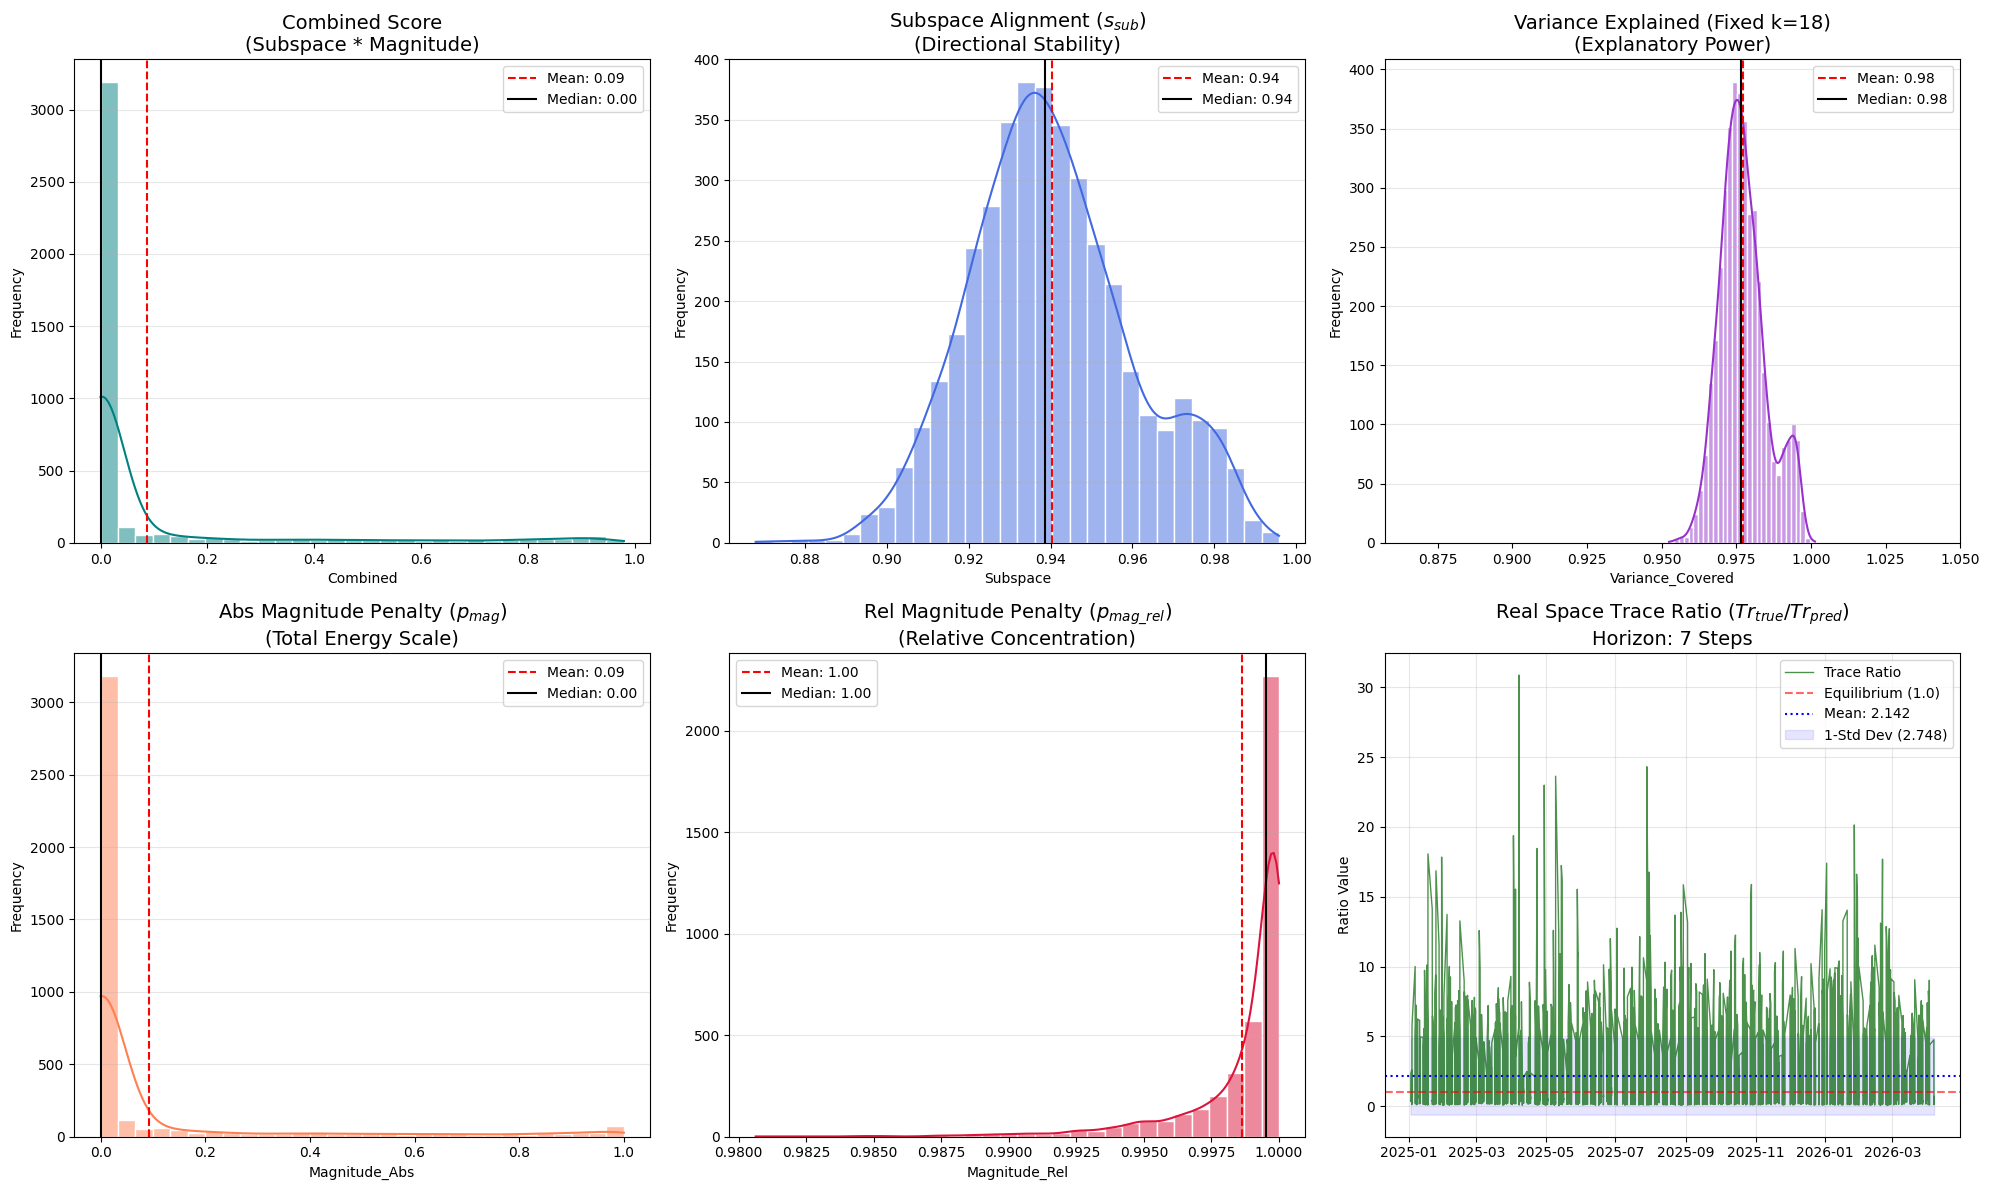

----------------------------------------
TRACE RATIO STATISTICS (REAL SPACE)
----------------------------------------
Mean Prediction:      2.142267
Standard Deviation:   2.747846
Coefficient of Var:   1.282682
----------------------------------------


In [4]:
# Initialization
dates = covariance_df.index
all_results = []
valid_dates = []

# Extraction Loop
for i in range(len(dates) - WindowSize):
    sigma_pred = covariance_df.iloc[i]['sigma']    
    sigma_true = covariance_df.iloc[i+WindowSize]['sigma']
    
    # Calculate Traces (Total Energy) in Real Space
    trace_curr = np.trace(sigma_pred)
    trace_next = np.trace(sigma_true)
    
    # Compute Energy Ratio (Real Space)
    # 1.0 = No change, >1.0 = Expansion, <1.0 = Decay
    energy_ratio = trace_next / trace_curr
    
    # Unpacking metrics from your covariance error function
    score, s_sub, p_mag, p_mag_norm, var_cov = calculate_covariance_error(
        sigma_true, sigma_pred, k=FIXED_K, tau=0.2
    )
    
    all_results.append({
        'Combined': score,
        'Subspace': s_sub,
        'Magnitude_Abs': p_mag,
        'Magnitude_Rel': p_mag_norm,
        'Variance_Covered': var_cov,
        'Trace_Ratio': energy_ratio
    })
    valid_dates.append(dates[i+WindowSize])

# Create DataFrame
res_df = pd.DataFrame(all_results, index=valid_dates)

# Calculate Statistics for the Real Space Trace Ratio
ratio_mean = res_df['Trace_Ratio'].mean()
ratio_std = res_df['Trace_Ratio'].std()

# --- Plotting ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

configs = [
    ('Combined', 'teal', 'Combined Score\n(Subspace * Magnitude)'),
    ('Subspace', 'royalblue', 'Subspace Alignment ($s_{sub}$)\n(Directional Stability)'),
    ('Variance_Covered', 'darkorchid', f'Variance Explained (Fixed k={FIXED_K})\n(Explanatory Power)'),
    ('Magnitude_Abs', 'coral', 'Abs Magnitude Penalty ($p_{mag}$)\n(Total Energy Scale)'),
    ('Magnitude_Rel', 'crimson', 'Rel Magnitude Penalty ($p_{mag\_rel}$)\n(Relative Concentration)')
]

# Plot the first 5 histograms
for i, (col, color, title) in enumerate(configs):
    sns.histplot(res_df[col], bins=30, kde=True, ax=axes[i], color=color, edgecolor='white')
    
    mu, med = res_df[col].mean(), res_df[col].median()
    axes[i].axvline(mu, color='red', linestyle='--', label=f'Mean: {mu:.2f}')
    axes[i].axvline(med, color='black', linestyle='-', label=f'Median: {med:.2f}')
    
    axes[i].set_title(title, fontsize=14)
    # axes[i].set_xlabel('Score / Percentage')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)
    
    if col == 'Variance_Covered':
        axes[i].set_xlim(res_df[col].min() * 0.9, 1.05)

# Plot 6: Real Space Trace Ratio Time Series
axes[5].plot(res_df.index, res_df['Trace_Ratio'], color='darkgreen', lw=1, alpha=0.7, label='Trace Ratio')
axes[5].axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Equilibrium (1.0)')
axes[5].axhline(ratio_mean, color='blue', linestyle=':', label=f'Mean: {ratio_mean:.3f}')

# Shade the 1-standard deviation band
axes[5].fill_between(res_df.index, ratio_mean - ratio_std, ratio_mean + ratio_std, 
                     color='blue', alpha=0.1, label=f'1-Std Dev ({ratio_std:.3f})')
axes[5].set_title(f'Real Space Trace Ratio ($Tr_{{true}} / Tr_{{pred}}$)\nHorizon: {WindowSize} Steps', fontsize=14)
axes[5].set_ylabel('Ratio Value')
axes[5].legend(loc='upper right')
axes[5].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print metrics to console
print("-" * 40)
print(f"TRACE RATIO STATISTICS (REAL SPACE)")
print("-" * 40)
print(f"Mean Prediction:      {ratio_mean:.6f}")
print(f"Standard Deviation:   {ratio_std:.6f}")
print(f"Coefficient of Var:   {ratio_std / ratio_mean:.6f}")
print("-" * 40)

# 3. Eigenvalue Information Coefficient (IC) & Hierarchy Stability
Having established that the eigenvector subspace is persistent, this section tests if the relative proportions of the eigenvalues are equally stable. By projecting the realized future covariance matrix onto the current principal basis, we calculate the cross-sectional Pearson (Linear) and Spearman (Rank) IC. High IC scores prove that the relative risk hierarchy is preserved over the 30-minute horizon, implying the only missing component for a perfect forecast is a single global variance scaling factor.

<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:63: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:63: SyntaxWarning: invalid escape sequence '\l'
C:\Users\yansh\AppData\Local\Temp\ipykernel_39992\2452897426.py:62: SyntaxWarning: invalid escape sequence '\l'
  ('log_total_variance', 'Log Universe Variance\n(Log Transform, $\lambda=0$)', 'teal', None),
C:\Users\yansh\AppData\Local\Temp\ipykernel_39992\2452897426.py:63: SyntaxWarning: invalid escape sequence '\l'
  ('boxcox_total_variance', f'Box-Cox Variance\n(Optimized $\lambda = {opt_lmbda:.3f}$)', 'crimson', None)


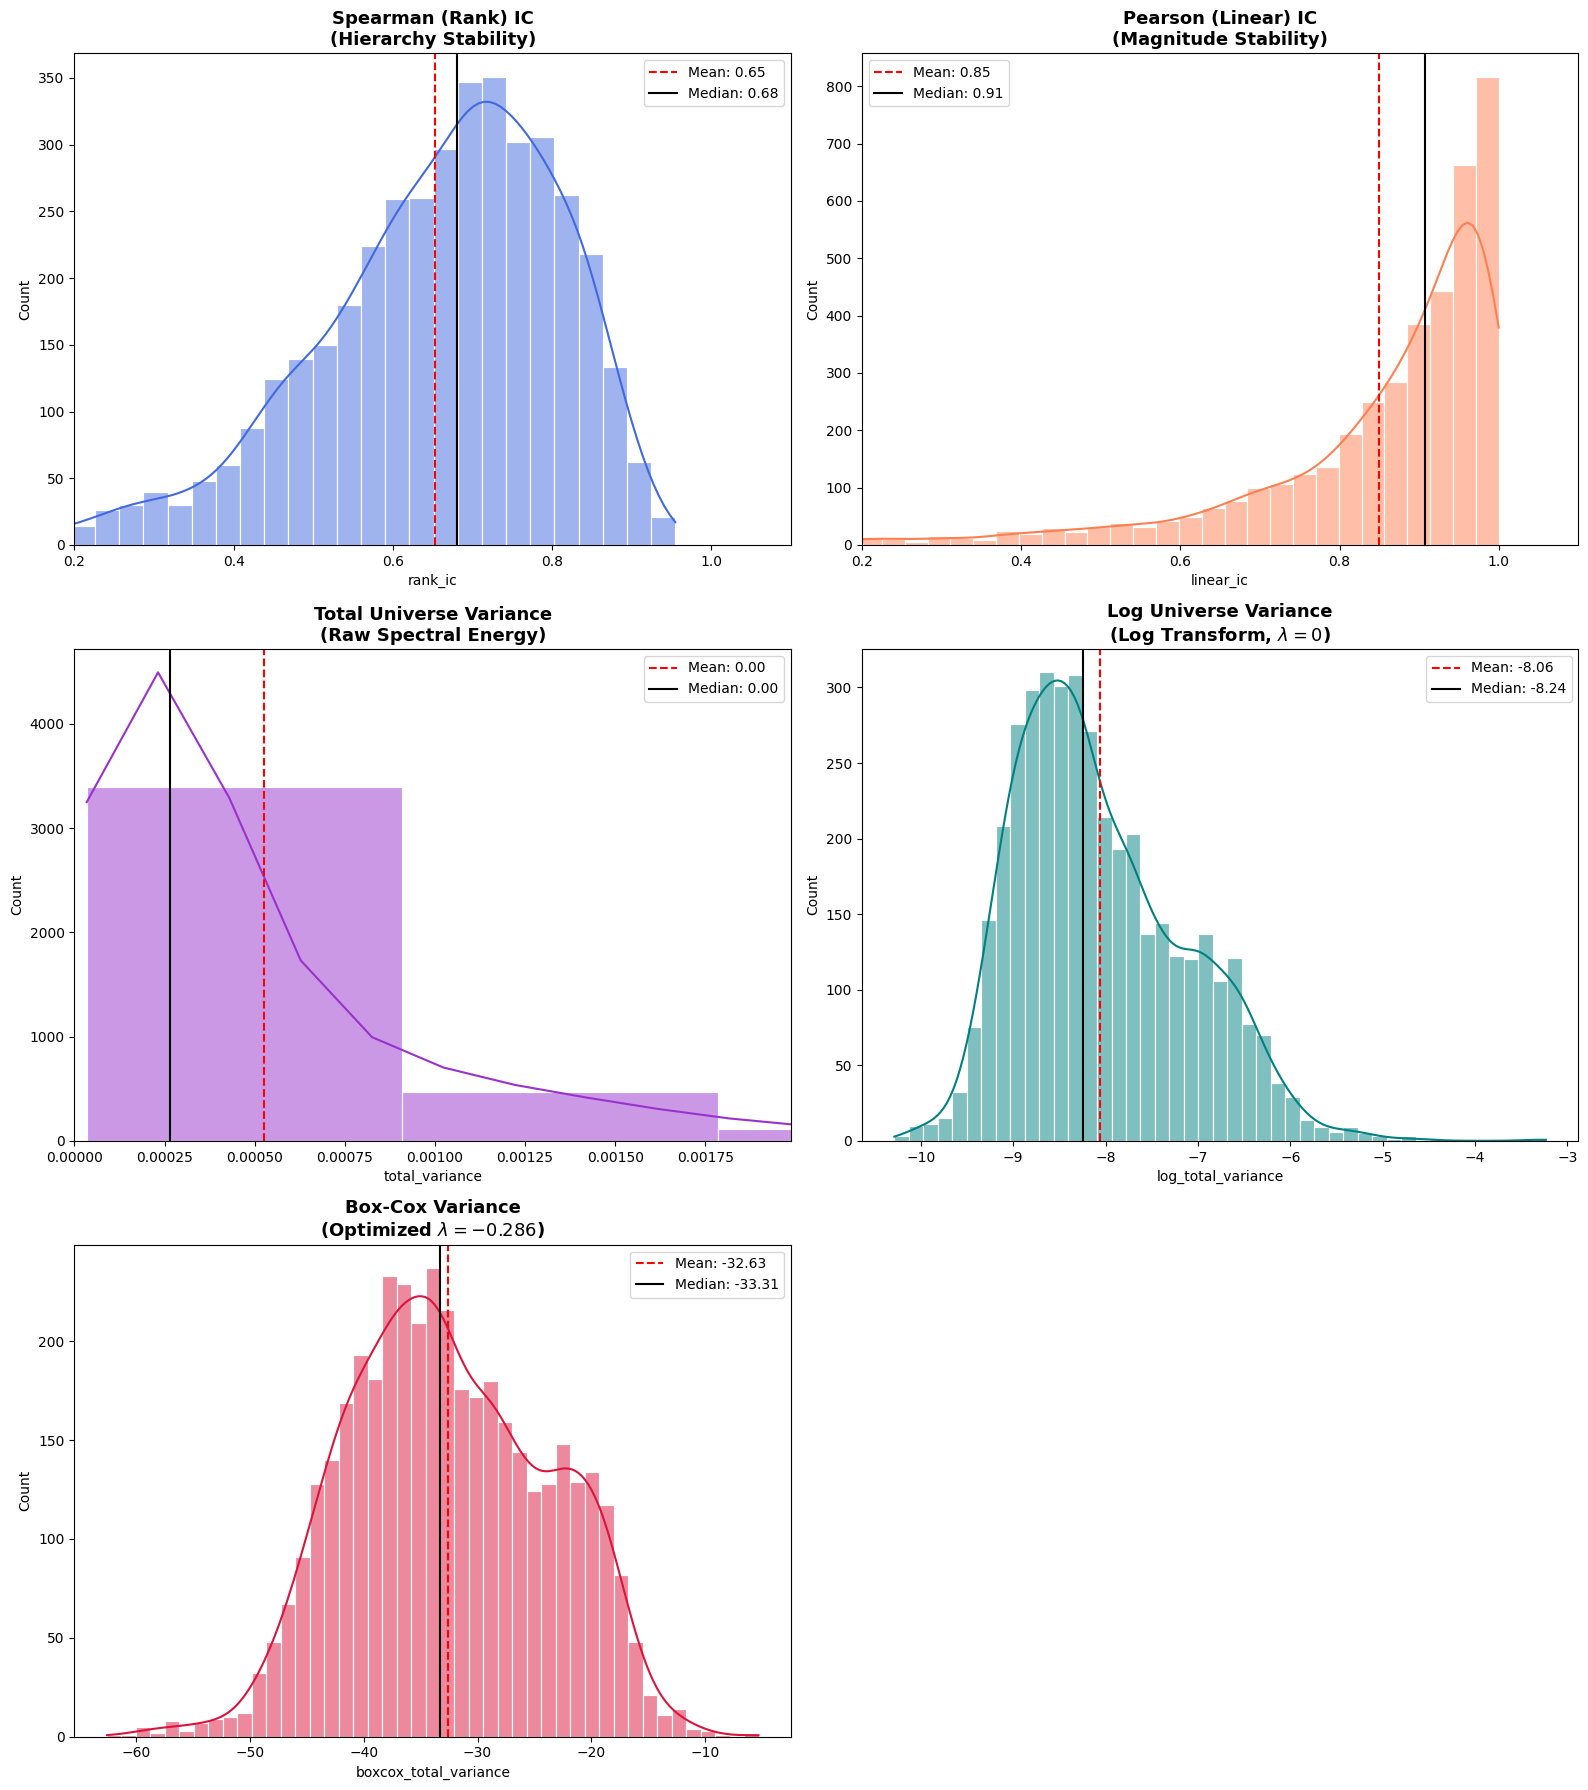

Optimal Lambda for Spectral Energy: -0.2856


In [5]:
def calculate_spectral_diagnostics(df, k, horizon):
    results = []
    dates = df.index
    
    # Pre-extract all raw variances to calculate optimal Box-Cox lambda globally
    all_variances = np.array([np.sum(np.diag(x)) for x in df['sigma']])
    # We apply Box-Cox on the target (future) values
    # Shift by epsilon if any zeros exist
    v_clean = all_variances[all_variances > 0]
    _, optimal_lambda = boxcox(v_clean)
    
    for i in range(len(df) - horizon):
        sigma_curr = df.iloc[i]['sigma']
        sigma_next = df.iloc[i + horizon]['sigma']
        
        # 1. Get Current Basis
        vals_c, vecs_c = np.linalg.eigh(sigma_curr)
        idx = np.argsort(vals_c)[::-1]
        v_curr = vals_c[idx][:k].flatten() 
        vecs_c_k = vecs_c[:, idx][:, :k]
        
        # 2. Project Future Sigma onto Current Basis
        sigma_future_projected = vecs_c_k.T @ sigma_next @ vecs_c_k
        v_next = np.diag(sigma_future_projected).flatten()
        
        # 3. Calculate Stability Metrics
        rank_ic, _ = spearmanr(v_curr, v_next)
        linear_ic, _ = pearsonr(v_curr, v_next)
        
        # 4. Total Variance and Transformations
        trace_next = np.sum(np.diag(sigma_next))
        
        # Apply the specific optimal lambda found for the dataset
        # Box-Cox: (y^lambda - 1) / lambda
        bc_variance = boxcox(trace_next, lmbda=optimal_lambda)
        
        results.append({
            'date': dates[i + horizon],
            'rank_ic': rank_ic,
            'linear_ic': linear_ic,
            'total_variance': trace_next,
            'log_total_variance': np.log(trace_next + 1e-9),
            'boxcox_total_variance': bc_variance,
            'opt_lambda': optimal_lambda
        })
        
    return pd.DataFrame(results).set_index('date')

# --- 1. Run Calculations ---
diag_df = calculate_spectral_diagnostics(covariance_df, FIXED_K, horizon=1)
opt_lmbda = diag_df['opt_lambda'].iloc[0]

# --- 2. Plotting 3-Row Diagnostic Dashboard ---
# Expanded to 3 rows to compare Raw vs Log vs Box-Cox
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

configs = [
    ('rank_ic', 'Spearman (Rank) IC\n(Hierarchy Stability)', 'royalblue', (0.2, 1.1)),
    ('linear_ic', 'Pearson (Linear) IC\n(Magnitude Stability)', 'coral', (0.2, 1.1)),
    ('total_variance', 'Total Universe Variance\n(Raw Spectral Energy)', 'darkorchid', None),
    ('log_total_variance', 'Log Universe Variance\n(Log Transform, $\lambda=0$)', 'teal', None),
    ('boxcox_total_variance', f'Box-Cox Variance\n(Optimized $\lambda = {opt_lmbda:.3f}$)', 'crimson', None)
]

for i, (col, title, color, xlim) in enumerate(configs):
    data = diag_df[col].dropna()
    sns.histplot(data, bins=45, kde=True, ax=axes[i], color=color, edgecolor='white')
    
    mu, med = data.mean(), data.median()
    axes[i].axvline(mu, color='red', linestyle='--', label=f'Mean: {mu:.2f}')
    axes[i].axvline(med, color='black', linestyle='-', label=f'Median: {med:.2f}')
    
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    if xlim: axes[i].set_xlim(xlim)
    
    if col == 'total_variance':
        axes[i].set_xlim(0, data.quantile(0.95) * 1.2)
    
    axes[i].legend()

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

print(f"Optimal Lambda for Spectral Energy: {opt_lmbda:.4f}")

# 4. Variance Scalar Predictability & Autocorrelation
To corroborate that the absolute energy scale (total market variance) can be predicted to rescale the stable eigenvectors, this section computes the autocorrelation function (ACF) of the matrix traces. The results show strong autocorrelation at early lags and cyclical daily lags (e.g., lag 13, representing a full 390-minute trading day at 30-minute horizons), validating the use of univariate forecasting models (like HAR) for future variance scaling.

In [6]:
trace_series = np.array([np.trace(matrix) for matrix in covariance_df['sigma']])

# --- 1. Variance Scale Transformations ---
opt_lambda = -0.226
log_trace = np.log(trace_series + 1e-9)
bc_trace = boxcox(trace_series, lmbda=opt_lambda)

# --- 2. Ratio (Energy Shift) Transformations ---
# Ratio: Vol_t / Vol_{t-1}
ratio_series = trace_series[1:] / trace_series[:-1]
log_ratio = np.log(ratio_series + 1e-9)
# Re-estimating lambda for the ratio as it has a different distribution than absolute scale
bc_ratio, opt_lambda_ratio = boxcox(ratio_series)

# --- 3. Autocorrelation Calculations ---
lags = 15
def get_acf(series): return acf(series, nlags=lags)[1:]

acf_df = pd.DataFrame({
    'Raw_Var': get_acf(trace_series),
    'Log_Var': get_acf(log_trace),
    'BC_Var':  get_acf(bc_trace),
    'Raw_Ratio': np.pad(get_acf(ratio_series), (0, 0)), # Energy Shift
    'Log_Ratio': np.pad(get_acf(log_ratio), (0, 0)),
    'BC_Ratio':  np.pad(get_acf(bc_ratio), (0, 0))
}, index=range(1, lags + 1))

print(f"--- Scale Persistence vs Ratio Persistence ---")
print(f"Var λ: {opt_lambda} | Ratio λ: {opt_lambda_ratio:.4f}")
print("-" * 65)
print(acf_df.round(4))

--- Scale Persistence vs Ratio Persistence ---
Var λ: -0.226 | Ratio λ: -0.7913
-----------------------------------------------------------------
    Raw_Var  Log_Var  BC_Var  Raw_Ratio  Log_Ratio  BC_Ratio
1    0.4734   0.7049  0.7188    -0.0522    -0.0035    0.0220
2    0.3242   0.4119  0.4348    -0.0987    -0.1985   -0.2094
3    0.1994   0.2361  0.2492    -0.0725    -0.0905   -0.0747
4    0.1480   0.1137  0.1156    -0.0630    -0.0545   -0.0431
5    0.1641   0.0238  0.0130    -0.0651    -0.0648   -0.0599
6    0.1355  -0.0281 -0.0466    -0.0670    -0.0811   -0.0924
7    0.1432  -0.0323 -0.0510    -0.0663    -0.0743   -0.0773
8    0.1474   0.0075 -0.0048    -0.0639    -0.0662   -0.0584
9    0.1233   0.0864  0.0859    -0.0583    -0.0478   -0.0415
10   0.1479   0.1938  0.2024    -0.0695    -0.0867   -0.0719
11   0.2390   0.3523  0.3681    -0.0940    -0.1786   -0.1698
12   0.3286   0.6164  0.6214    -0.0350     0.0518    0.1351
13   0.3606   0.8496  0.8400     0.7979     0.7982    0.5909
